In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [4]:
pd.read_csv('train.csv')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
pd.read_csv('test.csv')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
df_orginal=pd.concat([pd.read_csv('train.csv').drop(columns=['Survived']), pd.read_csv('test.csv')])

In [8]:
df_orginal.shape

(1309, 11)

In [9]:
df=df_orginal.copy(deep=True)

In [10]:
df=df.sample(1309)

In [14]:
df['Fare'].sample(30).tolist()

[15.2458,
 16.1,
 8.6625,
 108.9,
 7.25,
 18.0,
 7.125,
 8.9625,
 26.0,
 11.1333,
 8.05,
 7.25,
 34.375,
 39.0,
 164.8667,
 83.475,
 27.4458,
 26.0,
 10.5167,
 7.7958,
 7.8958,
 7.1417,
 78.2667,
 8.05,
 8.05,
 8.1125,
 16.1,
 15.0458,
 11.5,
 7.25]

In [23]:
sample=[]
samplestd=[]
for i in range(100):
    set=df['Fare'].dropna().sample(50)
    samplestd.append(set.std())
    sample.append(set.tolist())

sample=np.array(sample)
sample
    

array([[  7.2292, 146.5208,  35.5   , ...,   7.8958,  10.5   ,  26.    ],
       [ 27.4458,  26.55  ,   7.775 , ...,   7.7333,  13.    ,  27.7208],
       [  7.75  ,   8.05  ,  16.1   , ...,   7.7333,   8.05  ,  37.0042],
       ...,
       [  8.05  ,  25.4667,  18.75  , ...,  12.35  ,   9.5   ,   7.65  ],
       [ 73.5   ,   7.75  ,   9.35  , ..., 133.65  ,  19.2583,   7.8542],
       [  7.75  ,   0.    ,  31.275 , ...,  13.5   ,   7.8958,  12.7375]],
      shape=(100, 50))

In [24]:
sample_mean=np.mean(sample, axis=1)
sample_overall_std=np.mean(samplestd)
print(sample_overall_std)

49.459658422677265


<Axes: ylabel='Count'>

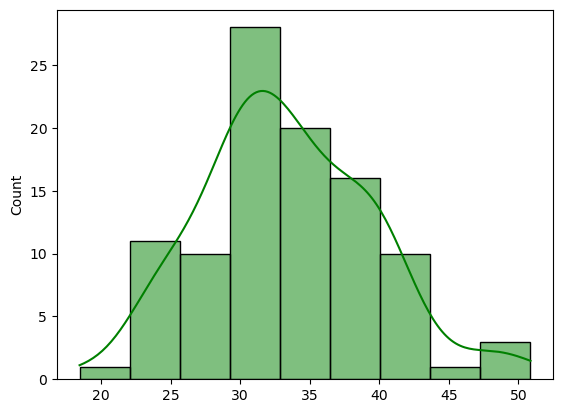

In [25]:
sns.histplot(data=sample_mean,color='green',kde=True)

In [ ]:
#in students t distribution the 95% confidence interval is +2.042 to -2.042
lower=sample_mean.mean()-2.042*(sample_overall_std/np.sqrt(50))
print(lower)
upper=sample_mean.mean()+2.042*(sample_overall_std/np.sqrt(50))
print(upper)

19.092341270788722
47.658499929211274
